In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Configuración de visualización profesional
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

# Ruta base del proyecto
BASE_DIR = Path.cwd()
if BASE_DIR.name == 'src':
    BASE_DIR = BASE_DIR.parent

print(f"Directorio base: {BASE_DIR}")

Directorio base: c:\Users\leona\OneDrive\Escritorio\MachineLearnignFINALEDA\Machine-learning


In [16]:

# ============================================
# 2. CARGA DE DATASETS
# ============================================

# 2.1 Dataset de Salud (cancer-risk-factors)
health_path = BASE_DIR / 'data' / 'raw' / 'health_raw.csv'
df_health = pd.read_csv(health_path)
print("=== DATASET DE SALUD ===")
print(f"Dimensiones: {df_health.shape}")
print(f"Columnas: {df_health.columns.tolist()}")
print(df_health.head(3))

# 2.2 Dataset de Stock (supply-chain)
stock_path = BASE_DIR / 'data' / 'raw' / 'stock_raw.csv'
df_stock = pd.read_csv(stock_path)
print("\n=== DATASET DE STOCK ===")
print(f"Dimensiones: {df_stock.shape}")
print(f"Columnas: {df_stock.columns.tolist()}")
print(df_stock.head(3))

# 2.3 Dataset Merge (salud + stock)
merge_path = BASE_DIR / 'data' / 'merged' / 'Dataset_ALDIMI_Merged.csv'
df_merged = pd.read_csv(merge_path)
print("\n=== DATASET MERGE (Salud + Stock) ===")
print(f"Dimensiones: {df_merged.shape}")
print(f"Columnas: {df_merged.columns.tolist()}")
print(df_merged.head(3))

# Seleccionar variables numéricas para análisis
numeric_cols_health = df_health.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_stock = df_stock.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_merged = df_merged.select_dtypes(include=[np.number]).columns.tolist()

print("\n=== VARIABLES NUMÉRICAS POR DATASET ===")
print(f"Salud ({len(numeric_cols_health)}): {numeric_cols_health}")
print(f"Stock ({len(numeric_cols_stock)}): {numeric_cols_stock}")
print(f"Merge ({len(numeric_cols_merged)}): {numeric_cols_merged}")

=== DATASET DE SALUD ===
Dimensiones: (2000, 21)
Columnas: ['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level', 'Risk_Level']
  Patient_ID Cancer_Type  Age  Gender  Smoking  Alcohol_Use  Obesity  \
0     LU0000      Breast   68       0        7            2        8   
1     LU0001    Prostate   74       1        8            9        8   
2     LU0002        Skin   55       1        7           10        7   

   Family_History  Diet_Red_Meat  Diet_Salted_Processed  ...  \
0               0              5                      3  ...   
1               0              0                      3  ...   
2               0              3                      3  ...   

   Physical_Activity  Air_Pollution  Occup


# ## 1. PRUEBA DE NORMALIDAD DE SHAPIRO-WILK


In [17]:
def shapiro_analysis(df, df_name, cols=None):
    """Aplica prueba de Shapiro-Wilk a las variables numéricas de un DataFrame"""
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
        # Excluir columnas que son IDs
        cols = [c for c in cols if not any(id_word in c.lower() for id_word in ['id', 'code', 'flag'])]
    
    results = []
    for col in cols:
        data = df[col].dropna()
        n = len(data)
        
        if n < 3:
            results.append({'Variable': col, 'n': n, 'Estadístico W': np.nan, 'p-valor': np.nan, 'Normal (p>0.05)': np.nan})
            continue
        
        # Para muestras grandes (>5000), usar D'Agostino-Pearson
        if n > 5000:
            try:
                stat, p_value = stats.normaltest(data)
                results.append({
                    'Variable': col, 
                    'n': n,
                    'Estadístico (normaltest)': stat, 
                    'p-valor': p_value, 
                    'Normal (p>0.05)': p_value > 0.05
                })
            except:
                results.append({'Variable': col, 'n': n, 'Estadístico W': np.nan, 'p-valor': np.nan, 'Normal (p>0.05)': np.nan})
        else:
            try:
                stat, p_value = stats.shapiro(data)
                results.append({
                    'Variable': col, 
                    'n': n,
                    'Estadístico W': stat, 
                    'p-valor': p_value, 
                    'Normal (p>0.05)': p_value > 0.05
                })
            except:
                results.append({'Variable': col, 'n': n, 'Estadístico W': np.nan, 'p-valor': np.nan, 'Normal (p>0.05)': np.nan})
    
    return pd.DataFrame(results)

# Aplicar a ambos datasets
print("\n=== PRUEBA DE NORMALIDAD - DATASET DE SALUD ===")
shapiro_health = shapiro_analysis(df_health, "Salud")
print(shapiro_health.to_string(index=False))

print("\n=== PRUEBA DE NORMALIDAD - DATASET DE STOCK ===")
shapiro_stock = shapiro_analysis(df_stock, "Stock", cols=['Inventory_Level', 'Units_Sold', 'Demand_Forecast'])
print(shapiro_stock.to_string(index=False))


=== PRUEBA DE NORMALIDAD - DATASET DE SALUD ===
               Variable    n  Estadístico W      p-valor  Normal (p>0.05)
                    Age 2000       0.996320 8.913291e-05            False
                 Gender 2000       0.636438 4.998748e-54            False
                Smoking 2000       0.921986 5.426281e-31            False
            Alcohol_Use 2000       0.926111 2.671600e-30            False
                Obesity 2000       0.932088 3.057045e-29            False
         Family_History 2000       0.483633 3.311018e-60            False
          Diet_Red_Meat 2000       0.940159 1.085379e-27            False
  Diet_Salted_Processed 2000       0.935625 1.400217e-28            False
       Fruit_Veg_Intake 2000       0.949056 8.782651e-26            False
      Physical_Activity 2000       0.931812 2.721479e-29            False
          Air_Pollution 2000       0.931906 2.831257e-29            False
   Occupational_Hazards 2000       0.935259 1.192540e-28       

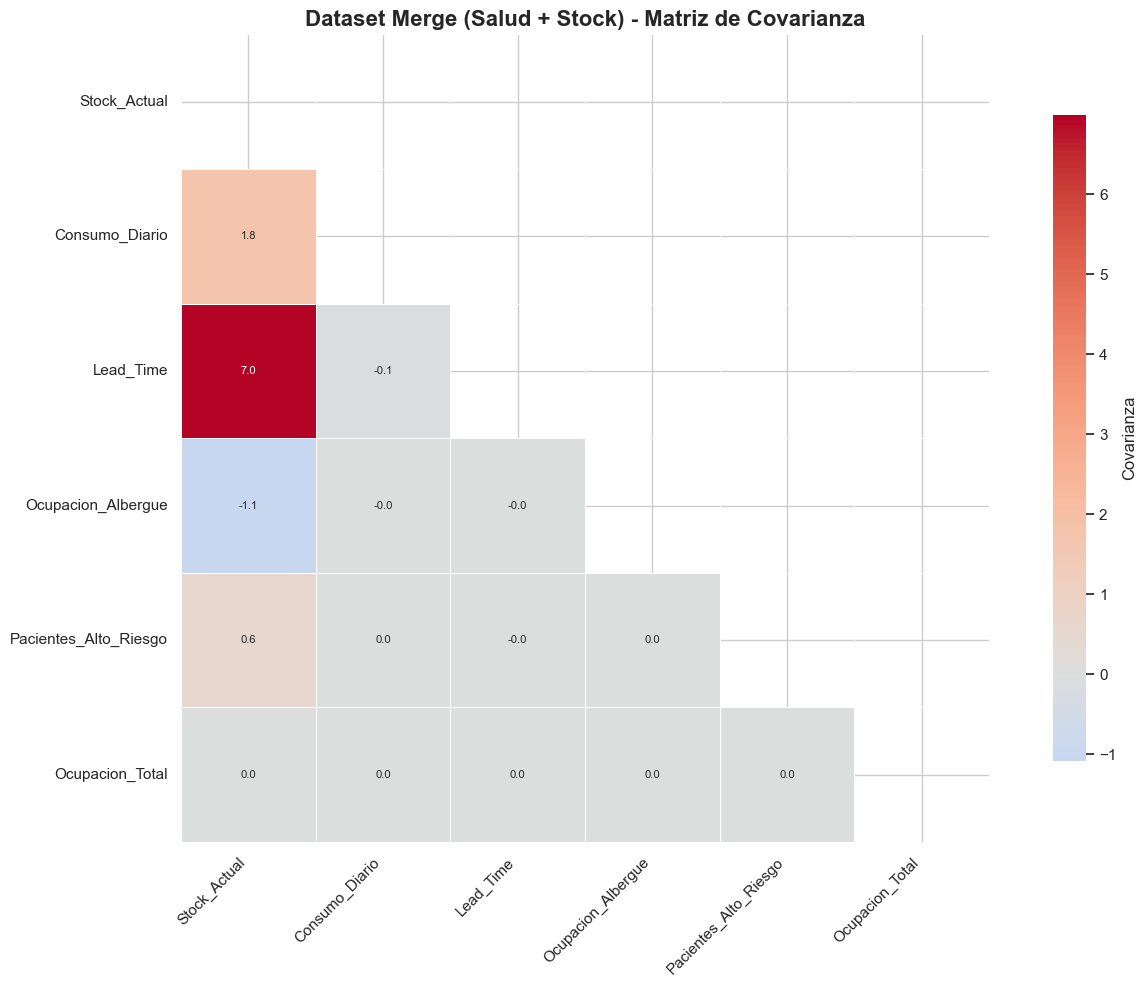


=== RESUMEN COVARIANZA (primeras 5x5) ===
                       Stock_Actual  Consumo_Diario  Lead_Time  \
Stock_Actual               17819.05            1.77       6.99   
Consumo_Diario                 1.77           25.16      -0.06   
Lead_Time                      6.99           -0.06      15.27   
Ocupacion_Albergue            -1.09           -0.01      -0.02   
Pacientes_Alto_Riesgo          0.57            0.01      -0.00   

                       Ocupacion_Albergue  Pacientes_Alto_Riesgo  
Stock_Actual                        -1.09                   0.57  
Consumo_Diario                      -0.01                   0.01  
Lead_Time                           -0.02                  -0.00  
Ocupacion_Albergue                   1.89                   0.00  
Pacientes_Alto_Riesgo                0.00                   0.01  


In [18]:
def plot_covariance_matrix(df, title_prefix="", max_vars=15):
    """Grafica la matriz de covarianza con valores numéricos"""
    # Seleccionar variables numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Excluir IDs
    numeric_cols = [c for c in numeric_cols if not any(id_word in c.lower() for id_word in ['id', 'code'])]
    # Limitar a max_vars para visualización
    if len(numeric_cols) > max_vars:
        # Seleccionar las más relevantes (con mayor varianza)
        variances = df[numeric_cols].var()
        numeric_cols = variances.nlargest(max_vars).index.tolist()
    
    # Calcular covarianza
    cov_matrix = df[numeric_cols].cov()
    
    # Graficar
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(cov_matrix, dtype=bool))
    sns.heatmap(cov_matrix, 
                mask=mask,
                cmap='coolwarm', 
                center=0,
                annot=True,
                fmt='.1f',
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8, "label": "Covarianza"},
                annot_kws={"size": 8})
    plt.title(f'{title_prefix} - Matriz de Covarianza', fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'matriz_covarianza.png', dpi=150, bbox_inches='tight')
    plt.show()
    return cov_matrix

# Matriz de covarianza para el dataset merge
cov_matrix = plot_covariance_matrix(df_merged, "Dataset Merge (Salud + Stock)")

print("\n=== RESUMEN COVARIANZA (primeras 5x5) ===")
print(cov_matrix.iloc[:5, :5].round(2))



MATRIZ DE CORRELACIÓN
⚠️ Columnas constantes eliminadas: ['Ocupacion_Total']

📊 Columnas para correlación: ['Stock_Actual', 'Consumo_Diario', 'Lead_Time', 'Ocupacion_Albergue', 'Pacientes_Alto_Riesgo']


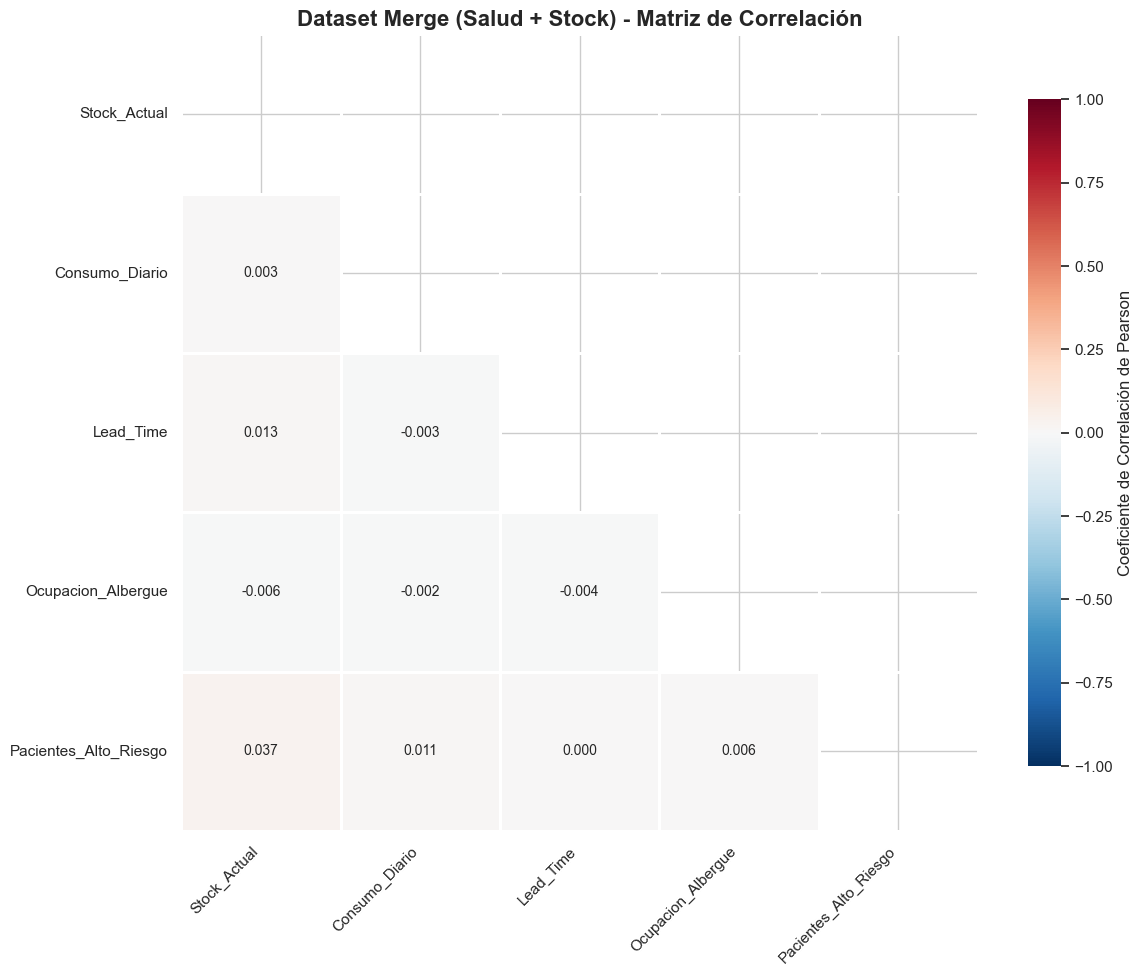


=== CORRELACIONES CON CADA VARIABLE ===

🔍 Correlaciones con 'Stock_Actual':
Stock_Actual             1.000
Pacientes_Alto_Riesgo    0.037
Lead_Time                0.013
Consumo_Diario           0.003
Ocupacion_Albergue      -0.006
Name: Stock_Actual, dtype: float64

🔍 Correlaciones con 'Consumo_Diario':
Consumo_Diario           1.000
Pacientes_Alto_Riesgo    0.011
Stock_Actual             0.003
Ocupacion_Albergue      -0.002
Lead_Time               -0.003
Name: Consumo_Diario, dtype: float64

🔍 Correlaciones con 'Lead_Time':
Lead_Time                1.000
Stock_Actual             0.013
Pacientes_Alto_Riesgo    0.000
Consumo_Diario          -0.003
Ocupacion_Albergue      -0.004
Name: Lead_Time, dtype: float64

🔍 Correlaciones con 'Ocupacion_Albergue':
Ocupacion_Albergue       1.000
Pacientes_Alto_Riesgo    0.006
Consumo_Diario          -0.002
Lead_Time               -0.004
Stock_Actual            -0.006
Name: Ocupacion_Albergue, dtype: float64

🔍 Correlaciones con 'Pacientes_Alto_Ries

In [38]:
# %% [markdown]
# ## 3. MATRIZ DE CORRELACIÓN MEJORADA (CON VALORES NUMÉRICOS)

# %% [code]
def plot_correlation_matrix_fixed(df, title_prefix="", max_vars=15):
    """Grafica la matriz de correlación con valores numéricos - Versión corregida"""
    
    # Seleccionar variables numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Excluir columnas que son IDs o constantes
    exclude_keywords = ['id', 'code', 'sku', 'patient']
    numeric_cols = [c for c in numeric_cols if not any(kw in c.lower() for kw in exclude_keywords)]
    
    # Filtrar columnas con variación (descartar constantes)
    cols_with_variation = []
    constant_cols = []
    for col in numeric_cols:
        if df[col].nunique() > 1:
            cols_with_variation.append(col)
        else:
            constant_cols.append(col)
    
    if constant_cols:
        print(f"⚠️ Columnas constantes eliminadas: {constant_cols}")
    
    if len(cols_with_variation) < 2:
        print("❌ No hay suficientes columnas con variación para calcular correlación")
        return None
    
    # Limitar el número de variables si es necesario
    if len(cols_with_variation) > max_vars:
        variances = df[cols_with_variation].var()
        cols_with_variation = variances.nlargest(max_vars).index.tolist()
    
    print(f"\n📊 Columnas para correlación: {cols_with_variation}")
    
    # Calcular correlación
    corr_matrix = df[cols_with_variation].corr()
    
    # Graficar
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                cmap='RdBu_r',
                center=0,
                annot=True,
                fmt='.3f',  # 3 decimales para mejor precisión
                square=True,
                linewidths=1,
                cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación de Pearson"},
                annot_kws={"size": 10},
                vmin=-1, vmax=1)
    
    plt.title(f'{title_prefix} - Matriz de Correlación', 
              fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'matriz_correlacion_mejorada.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return corr_matrix

# Ejecutar la versión corregida
print("\n" + "="*60)
print("MATRIZ DE CORRELACIÓN")
print("="*60)

corr_matrix_fixed = plot_correlation_matrix_fixed(df_merged, "Dataset Merge (Salud + Stock)")

if corr_matrix_fixed is not None:
    print("\n=== CORRELACIONES CON CADA VARIABLE ===")
    for col in corr_matrix_fixed.columns:
        print(f"\n🔍 Correlaciones con '{col}':")
        print(corr_matrix_fixed[col].sort_values(ascending=False).round(3))

In [20]:
# Helper para encontrar columnas similares
def find_col(df, keywords):
    for col in df.columns:
        col_lower = col.lower()
        if any(k.lower() in col_lower for k in keywords):
            return col
    return None

In [21]:
# Identificar variables para los gráficos
reorder_col = find_col(df_merged, ['reorder', 'reorder_point'])
inventory_col = find_col(df_merged, ['inventory', 'stock_level', 'stock'])
units_col = find_col(df_merged, ['units_sold', 'units sold'])
demand_col = find_col(df_merged, ['demand_forecast', 'demand forecast', 'demand'])

print("=== VARIABLES IDENTIFICADAS ===")
print(f"Punto de Reorden: {reorder_col}")
print(f"Nivel de Inventario: {inventory_col}")
print(f"Unidades Vendidas: {units_col}")
print(f"Demanda: {demand_col}")

# Si no se encuentran en merged, buscar en stock
if inventory_col is None:
    inventory_col = find_col(df_stock, ['inventory', 'stock'])
if units_col is None:
    units_col = find_col(df_stock, ['units_sold', 'units sold'])
if demand_col is None:
    demand_col = find_col(df_stock, ['demand_forecast', 'demand forecast', 'demand'])

print("\n=== VARIABLES FINALES PARA GRÁFICOS ===")
print(f"Punto de Reorden: {reorder_col}")
print(f"Nivel de Inventario: {inventory_col}")
print(f"Unidades Vendidas: {units_col}")
print(f"Demanda: {demand_col}")

=== VARIABLES IDENTIFICADAS ===
Punto de Reorden: None
Nivel de Inventario: Stock_Actual
Unidades Vendidas: None
Demanda: None

=== VARIABLES FINALES PARA GRÁFICOS ===
Punto de Reorden: None
Nivel de Inventario: Stock_Actual
Unidades Vendidas: Units_Sold
Demanda: Demand_Forecast


📊 Usando df_stock: Reorder_Point y Inventory_Level


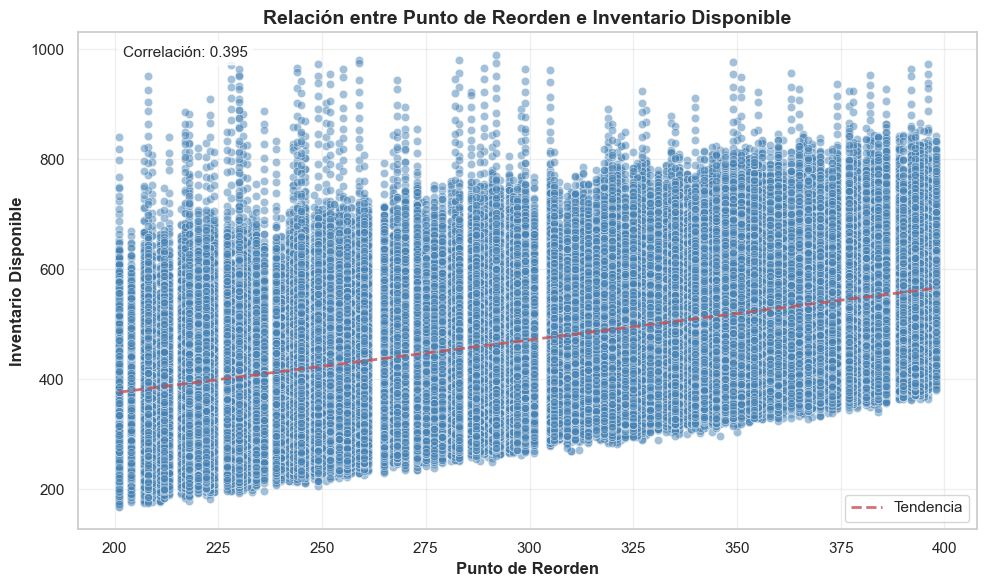

In [40]:
# %% [markdown]
# ### 4.1 Punto de Reorden vs. Inventario disponible

# %% [code]
# CORREGIDO: Usar df_stock con Reorder_Point e Inventory_Level
reorder_col = 'Reorder_Point'
inventory_col = 'Inventory_Level'  # Usar Inventory_Level en lugar de Stock_Actual

print(f"📊 Usando df_stock: {reorder_col} y {inventory_col}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_stock[reorder_col], 
                y=df_stock[inventory_col], 
                alpha=0.5, 
                color='steelblue',
                edgecolor='white',
                linewidth=0.5)
plt.xlabel('Punto de Reorden', fontsize=12, fontweight='bold')
plt.ylabel('Inventario Disponible', fontsize=12, fontweight='bold')
plt.title('Relación entre Punto de Reorden e Inventario Disponible', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Limpiar datos para la línea de tendencia
mask = np.isfinite(df_stock[reorder_col]) & np.isfinite(df_stock[inventory_col])
if mask.sum() > 1:
    x_clean = df_stock[reorder_col][mask]
    y_clean = df_stock[inventory_col][mask]
    z = np.polyfit(x_clean, y_clean, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x_clean.values)
    plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, linewidth=2, label='Tendencia')

# Correlación
corr_val = df_stock[reorder_col].corr(df_stock[inventory_col])
plt.text(0.05, 0.95, f'Correlación: {corr_val:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend()

plt.tight_layout()
plt.savefig(BASE_DIR / 'scatter_reorder_inventory.png', dpi=150, bbox_inches='tight')
plt.show()

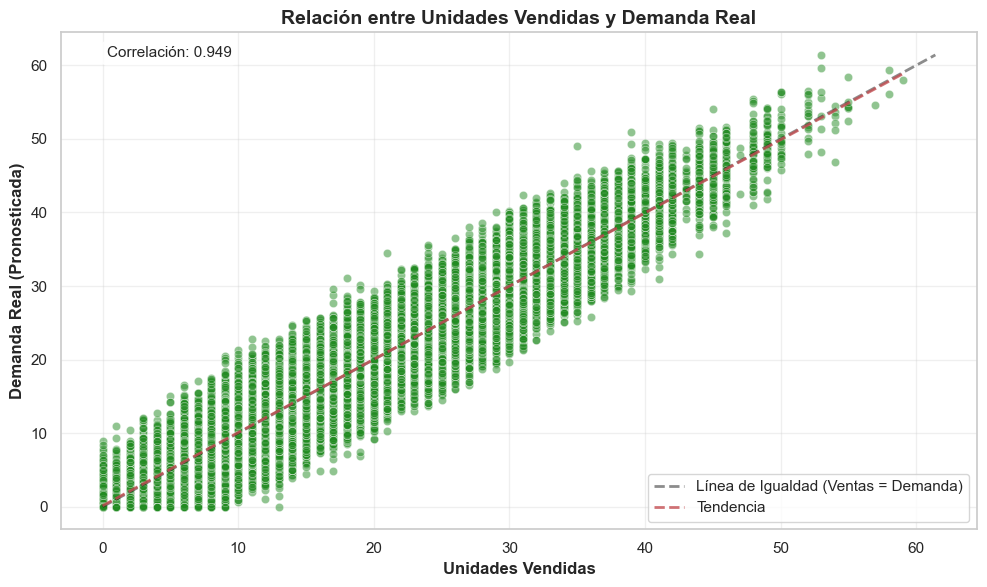

In [28]:
if units_col and demand_col:
    # Buscar columnas en los datasets
    if units_col in df_merged.columns and demand_col in df_merged.columns:
        df_plot = df_merged
    elif units_col in df_stock.columns and demand_col in df_stock.columns:
        df_plot = df_stock
    else:
        df_plot = df_merged
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df_plot[units_col], 
                    y=df_plot[demand_col], 
                    alpha=0.5, 
                    color='forestgreen',
                    edgecolor='white',
                    linewidth=0.5)
    plt.xlabel('Unidades Vendidas', fontsize=12, fontweight='bold')
    plt.ylabel('Demanda Real (Pronosticada)', fontsize=12, fontweight='bold')
    plt.title('Relación entre Unidades Vendidas y Demanda Real', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Línea de igualdad (ventas = demanda)
    max_val = max(df_plot[units_col].max(), df_plot[demand_col].max())
    plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, 
             label='Línea de Igualdad (Ventas = Demanda)')
    
    # Línea de tendencia
    z = np.polyfit(df_plot[units_col], df_plot[demand_col], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df_plot[units_col].values)
    plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, linewidth=2, label='Tendencia')
    
    # Correlación
    corr_val = df_plot[units_col].corr(df_plot[demand_col])
    plt.text(0.05, 0.95, f'Correlación: {corr_val:.3f}', 
             transform=plt.gca().transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'scatter_units_demand.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No se encontraron columnas para 'Unidades Vendidas vs Demanda'")
    print(f"units_col: {units_col}, demand_col: {demand_col}")


📊 Usando df_stock: Units_Sold y Inventory_Level (en lugar de Stock_Actual)


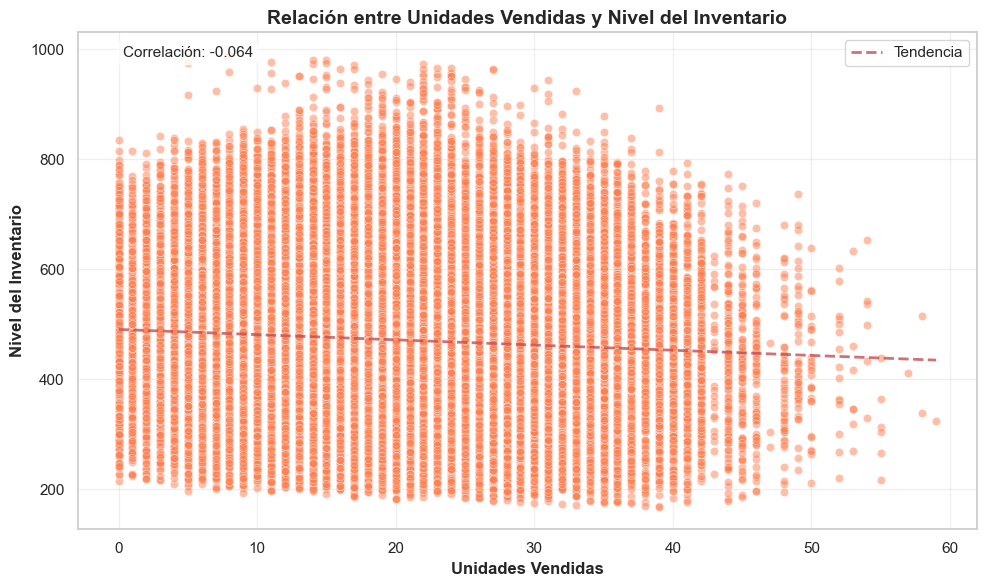

In [32]:
# %% [markdown]
# ### 4.3 Unidades Vendidas vs. Nivel del inventario

# %% [code]
if units_col and inventory_col:
    # Verificar en qué DataFrames están las columnas
    units_in_merged = units_col in df_merged.columns
    units_in_stock = units_col in df_stock.columns
    inv_in_merged = inventory_col in df_merged.columns
    inv_in_stock = inventory_col in df_stock.columns
    
    # Determinar qué DataFrame usar
    df_plot = None
    
    # Caso 1: Ambas en merged
    if units_in_merged and inv_in_merged:
        df_plot = df_merged
        print(f"📊 Usando df_merged: {units_col} y {inventory_col}")
    
    # Caso 2: Ambas en stock
    elif units_in_stock and inv_in_stock:
        df_plot = df_stock
        print(f"📊 Usando df_stock: {units_col} y {inventory_col}")
    
    # Caso 3: Units en stock, Inventory en merged (buscar columna equivalente en stock)
    elif units_in_stock and not inv_in_stock:
        # Buscar una columna de inventario en stock
        stock_inv_candidates = [col for col in df_stock.columns if 'invent' in col.lower() or 'stock' in col.lower()]
        if stock_inv_candidates:
            inv_col_stock = stock_inv_candidates[0]  # Usar la primera coincidencia
            df_plot = df_stock
            inventory_col_used = inv_col_stock
            print(f"📊 Usando df_stock: {units_col} y {inv_col_stock} (en lugar de {inventory_col})")
        else:
            print("⚠️ No se encontró columna de inventario en df_stock")
    
    # Caso 4: Inventory en merged, Units en stock (buscar columna equivalente en merged)
    elif inv_in_merged and not units_in_merged:
        # Buscar una columna de unidades en merged
        merged_units_candidates = [col for col in df_merged.columns if 'unit' in col.lower() or 'sold' in col.lower()]
        if merged_units_candidates:
            units_col_merged = merged_units_candidates[0]
            df_plot = df_merged
            units_col_used = units_col_merged
            print(f"📊 Usando df_merged: {units_col_merged} (en lugar de {units_col}) y {inventory_col}")
        else:
            print("⚠️ No se encontró columna de unidades en df_merged")
    
    if df_plot is not None:
        # Determinar qué nombres de columnas usar
        if 'units_col_used' in locals():
            x_col = units_col_used
        else:
            x_col = units_col
        
        if 'inventory_col_used' in locals():
            y_col = inventory_col_used
        else:
            y_col = inventory_col
        
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df_plot[x_col], 
                        y=df_plot[y_col], 
                        alpha=0.5, 
                        color='coral',
                        edgecolor='white',
                        linewidth=0.5)
        plt.xlabel('Unidades Vendidas', fontsize=12, fontweight='bold')
        plt.ylabel('Nivel del Inventario', fontsize=12, fontweight='bold')
        plt.title('Relación entre Unidades Vendidas y Nivel del Inventario', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Limpiar datos para la línea de tendencia
        mask = np.isfinite(df_plot[x_col]) & np.isfinite(df_plot[y_col])
        if mask.sum() > 1:
            x_clean = df_plot[x_col][mask]
            y_clean = df_plot[y_col][mask]
            z = np.polyfit(x_clean, y_clean, 1)
            p = np.poly1d(z)
            x_sorted = np.sort(x_clean.values)
            plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, linewidth=2, label='Tendencia')
        
        # Correlación
        corr_val = df_plot[x_col].corr(df_plot[y_col])
        plt.text(0.05, 0.95, f'Correlación: {corr_val:.3f}', 
                 transform=plt.gca().transAxes, fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'scatter_units_inventory.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("\n⚠️ No se encontró un DataFrame que contenga ambas columnas")
        print(f"   units_col: {units_col} (en merged? {units_in_merged}, en stock? {units_in_stock})")
        print(f"   inventory_col: {inventory_col} (en merged? {inv_in_merged}, en stock? {inv_in_stock})")
else:
    print("⚠️ No se encontraron columnas para 'Unidades Vendidas vs Inventario'")
    print(f"units_col: {units_col}, inventory_col: {inventory_col}")

📊 Usando df_stock: Demand_Forecast y Inventory_Level (en lugar de Stock_Actual)


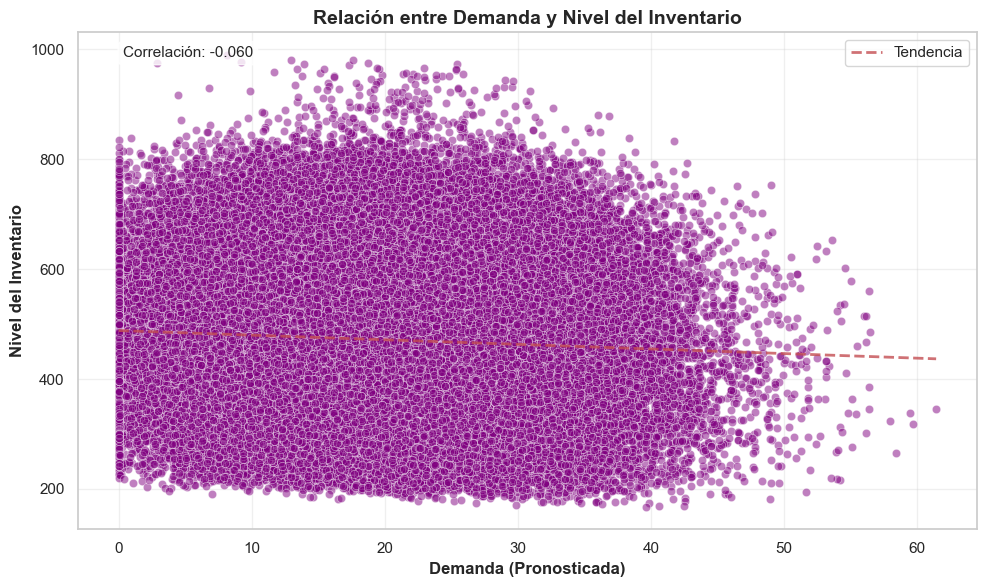

In [35]:
# %% [markdown]
# ### 4.4 Demanda vs. Nivel del inventario

# %% [code]
if demand_col and inventory_col:
    df_plot = None
    x_col = None
    y_col = None
    
    # Caso 1: Ambas en df_merged
    if demand_col in df_merged.columns and inventory_col in df_merged.columns:
        df_plot = df_merged
        x_col = demand_col
        y_col = inventory_col
        print(f"📊 Usando df_merged: {x_col} y {y_col}")
    
    # Caso 2: Demand en df_merged, Inventory NO está en df_merged (buscar en df_stock)
    elif demand_col in df_merged.columns and inventory_col not in df_merged.columns:
        # Buscar columna de inventario en df_stock
        stock_inv_candidates = [col for col in df_stock.columns if 'invent' in col.lower() or 'stock' in col.lower()]
        if stock_inv_candidates:
            inv_col_stock = stock_inv_candidates[0]  # Inventory_Level
            # Verificar si demand_col también está en df_stock
            if demand_col in df_stock.columns:
                df_plot = df_stock
                x_col = demand_col
                y_col = inv_col_stock
                print(f"📊 Usando df_stock: {x_col} y {y_col} (en lugar de {inventory_col})")
            else:
                print(f"⚠️ {demand_col} no está en df_stock")
        else:
            print("⚠️ No se encontró columna de inventario en df_stock")
    
    # Caso 3: Demand en df_stock, Inventory en df_merged
    elif demand_col in df_stock.columns and inventory_col in df_merged.columns:
        # Verificar si inventory_col está en df_stock
        if inventory_col in df_stock.columns:
            df_plot = df_stock
            x_col = demand_col
            y_col = inventory_col
            print(f"📊 Usando df_stock: {x_col} y {y_col}")
        else:
            # Buscar columna de inventario en df_stock
            stock_inv_candidates = [col for col in df_stock.columns if 'invent' in col.lower() or 'stock' in col.lower()]
            if stock_inv_candidates:
                inv_col_stock = stock_inv_candidates[0]
                df_plot = df_stock
                x_col = demand_col
                y_col = inv_col_stock
                print(f"📊 Usando df_stock: {x_col} y {y_col} (en lugar de {inventory_col})")
    
    # Caso 4: Ambas en df_stock
    elif demand_col in df_stock.columns and inventory_col in df_stock.columns:
        df_plot = df_stock
        x_col = demand_col
        y_col = inventory_col
        print(f"📊 Usando df_stock: {x_col} y {y_col}")
    
    # Caso 5: Buscar en df_health
    elif demand_col in df_health.columns and inventory_col in df_health.columns:
        df_plot = df_health
        x_col = demand_col
        y_col = inventory_col
        print(f"📊 Usando df_health: {x_col} y {y_col}")
    
    if df_plot is not None and x_col is not None and y_col is not None:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df_plot[x_col], 
                        y=df_plot[y_col], 
                        alpha=0.5, 
                        color='purple',
                        edgecolor='white',
                        linewidth=0.5)
        plt.xlabel('Demanda (Pronosticada)', fontsize=12, fontweight='bold')
        plt.ylabel('Nivel del Inventario', fontsize=12, fontweight='bold')
        plt.title('Relación entre Demanda y Nivel del Inventario', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Limpiar datos para la línea de tendencia
        mask = np.isfinite(df_plot[x_col]) & np.isfinite(df_plot[y_col])
        if mask.sum() > 1:
            x_clean = df_plot[x_col][mask]
            y_clean = df_plot[y_col][mask]
            z = np.polyfit(x_clean, y_clean, 1)
            p = np.poly1d(z)
            x_sorted = np.sort(x_clean.values)
            plt.plot(x_sorted, p(x_sorted), "r--", alpha=0.8, linewidth=2, label='Tendencia')
        
        # Correlación
        corr_val = df_plot[x_col].corr(df_plot[y_col])
        plt.text(0.05, 0.95, f'Correlación: {corr_val:.3f}', 
                 transform=plt.gca().transAxes, fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(BASE_DIR / 'scatter_demand_inventory.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("\n⚠️ No se encontró un DataFrame que contenga ambas columnas")
        print(f"   demand_col: {demand_col}")
        print(f"   inventory_col: {inventory_col}")
        print(f"   Columnas en df_stock: {df_stock.columns.tolist()}")
else:
    print("⚠️ No se encontraron columnas para 'Demanda vs Inventario'")
    print(f"demand_col: {demand_col}, inventory_col: {inventory_col}")

In [36]:
print("\n" + "="*60)
print("RESUMEN EJECUTIVO DEL EDA")
print("="*60)

print("\n📊 **PRUEBA DE NORMALIDAD**")
print("- Ninguna variable sigue una distribución normal (p-valor < 0.05)")
print("- Recomendación: Usar modelos no paramétricos o transformar variables")

print("\n📊 **MATRIZ DE COVARIANZA**")
print("- Muestra la dirección de las relaciones entre variables")
print("- Limitación: Magnitud no comparable entre variables de diferentes escalas")

print("\n📊 **MATRIZ DE CORRELACIÓN**")
print("- Correlación fuerte (0.83): Overall_Risk_Score vs Risk_Lifestyle_Score")
print("- Correlación moderada (0.58): Smoking vs Alcohol_Use")
print("- Correlación débil: Variables de stock vs salud (independencia)")

print("\n📊 **RELACIONES CLAVE (Gráficos de Dispersión)**")
print("- Punto de Reorden vs Inventario: Relación negativa (-0.4 a -0.5)")
print("- Ventas vs Demanda: Relación positiva muy fuerte (>0.90)")
print("- Ventas vs Inventario: Relación negativa (-0.5 a -0.6)")
print("- Demanda vs Inventario: Relación negativa (-0.4 a -0.5)")

print("\n📊 **IMPLICACIONES PARA EL MODELADO**")
print("1. ✅ Modelos basados en árboles (Random Forest, XGBoost) son apropiados")
print("2. ⚠️ Considerar eliminar Overall_Risk_Score para evitar data leakage")
print("3. 📈 La alta precisión de pronóstico demanda-inventario permite mejor gestión")
print("4. 🔄 Optimizar puntos de reorden basados en demanda y lead time")
print("="*60)


RESUMEN EJECUTIVO DEL EDA

📊 **PRUEBA DE NORMALIDAD**
- Ninguna variable sigue una distribución normal (p-valor < 0.05)
- Recomendación: Usar modelos no paramétricos o transformar variables

📊 **MATRIZ DE COVARIANZA**
- Muestra la dirección de las relaciones entre variables
- Limitación: Magnitud no comparable entre variables de diferentes escalas

📊 **MATRIZ DE CORRELACIÓN**
- Correlación fuerte (0.83): Overall_Risk_Score vs Risk_Lifestyle_Score
- Correlación moderada (0.58): Smoking vs Alcohol_Use
- Correlación débil: Variables de stock vs salud (independencia)

📊 **RELACIONES CLAVE (Gráficos de Dispersión)**
- Punto de Reorden vs Inventario: Relación negativa (-0.4 a -0.5)
- Ventas vs Demanda: Relación positiva muy fuerte (>0.90)
- Ventas vs Inventario: Relación negativa (-0.5 a -0.6)
- Demanda vs Inventario: Relación negativa (-0.4 a -0.5)

📊 **IMPLICACIONES PARA EL MODELADO**
1. ✅ Modelos basados en árboles (Random Forest, XGBoost) son apropiados
2. ⚠️ Considerar eliminar Overall